# Subsystem 2 — Cohort clustering (UC2)

UC2 asks the profiling algorithm to *"identify patterns across literacy … indicators"*, and the
PM3 class diagram declares `ProfilingAlgorithm.cluster(records) : Cluster[]`. This notebook is
the working-out behind that method: it audits `DIAL_Anonymised_Data.xlsx`, establishes which
columns are legitimate clustering features and at what scope, chooses **k** by silhouette score,
and visualises the result the way the dashboard will.

**The logic lives in the app, not in this notebook.** Every cell below imports from
`app.ingestion.dial_workbook` and `app.agents.profiling_algorithm` — the same modules
`scripts/ingest_dial_data.py` calls. The notebook explains and evidences; it never
re-implements. That is what stops the picture here from drifting away from the rows in Supabase.

Three findings in §2 do most of the work, and each one removes something that looked like a
feature. The headline result is in §5.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# backend/ on the path so `app.*` resolves — this notebook lives one level up in notebooks/.
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "backend"))

from app.ingestion.dial_workbook import (
    load_workbook, latest_per_student, coverage, writing_genre_audit,
    CLUSTER_FEATURES, PLOT_FEATURES, GENRE_COLUMNS,
)
from app.agents.profiling_algorithm import ProfilingAlgorithm, K_MIN, K_MAX, RANDOM_STATE

WORKBOOK = ROOT / "DIAL_Anonymised_Data.xlsx"
algo = ProfilingAlgorithm()
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("workbook:", WORKBOOK.name, f"({WORKBOOK.stat().st_size/1e6:.1f} MB)")

workbook: DIAL_Anonymised_Data.xlsx (3.7 MB)


## 1 · Load and reduce to one row per student

A workbook row is one **sitting** — a student assessed in one semester. Students recur across the
nine semesters on record, so clustering first reduces the sheet to each student's *most recent*
sitting.

Recency is the `semester` string, which sorts chronologically as text. Ties (a student with two
rows in the same semester — 22 such pairs) fall through to the latest subtest date and then to
workbook order, so the reduction is deterministic: a re-ingest can never reshuffle who is in
which cluster.

In [2]:
sittings = load_workbook(WORKBOOK)
cohort   = latest_per_student(sittings)

print(f"sittings          {len(sittings):>7,}")
print(f"unique students   {sittings.student_id.nunique():>7,}")
print(f"after reduction   {len(cohort):>7,}   <- one row per student")
assert len(cohort) == cohort.student_id.nunique()

sittings.groupby("student_id").size().value_counts().sort_index().rename("students").to_frame().T

sittings           22,892
unique students     5,783
after reduction     5,783   <- one row per student


,1,2,3,4,5,6,7,8,9,10
students,1055,1180,669,751,468,549,306,558,244,3


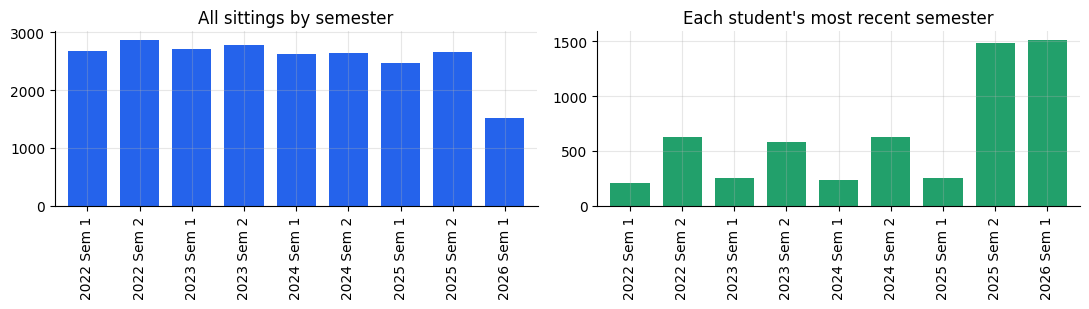

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
sittings.semester.value_counts().sort_index().plot.bar(ax=ax[0], color="#2563EB", width=.75)
ax[0].set_title("All sittings by semester"); ax[0].set_xlabel("")
cohort.semester.value_counts().sort_index().plot.bar(ax=ax[1], color="#22A06B", width=.75)
ax[1].set_title("Each student's most recent semester"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

The right-hand panel is the cohort we cluster. It leans recent — over half were last assessed in
2025 Sem 2 or 2026 Sem 1 — but a long tail was last seen years ago. That tail is real: those
learners are still on the caseload and the profile we hold for them is simply older.

## 2 · Feature audit

Which columns can actually separate learners? `distinct` is the one to watch — these are coarse
rubric marks, not continuous measures.

In [4]:
coverage(cohort, CLUSTER_FEATURES + GENRE_COLUMNS + ("fluency_mark",))

,feature,present,missing,zero,min,max,mean,sd,distinct
0,phonics,5783,0,139,0.0,46.0,22.60,13.05,47
1,word_reading_accuracy,5783,0,58,0.0,10.0,8.55,1.64,11
2,word_spelling,5783,0,543,0.0,10.0,5.54,3.22,11
3,narrative_writing,3769,2014,912,0.0,24.0,9.95,6.97,25
4,exposition_writing,3769,2014,3119,0.0,24.0,2.63,6.02,24
5,persuasive_writing,3769,2014,3577,0.0,24.0,0.80,3.56,21
6,fluency_mark,4855,928,0,16.0,20.0,18.16,1.58,3


### 2a · `FluencyMark` is `Word_Reading_Accuracy` in disguise

Not a second measurement: it is `2 × WRA`, gated at 8, and null below that.

In [5]:
xt = pd.crosstab(sittings.word_reading_accuracy, sittings.fluency_mark.fillna("(null)"))
print("FluencyMark (columns) x Word_Reading_Accuracy (rows) — all 22,892 sittings\n")
print(xt.to_string())

pairs = sittings.dropna(subset=["fluency_mark", "word_reading_accuracy"])
print(f"\nrows satisfying fluency == 2 x WRA: {(pairs.fluency_mark == 2*pairs.word_reading_accuracy).mean():.1%}")
print(f"Pearson r: {pairs.fluency_mark.corr(pairs.word_reading_accuracy):.4f}")

FluencyMark (columns) x Word_Reading_Accuracy (rows) — all 22,892 sittings

fluency_mark           16.0  18.0  20.0  (null)
word_reading_accuracy                          
0.0                       0     0     0     296
1.0                       0     0     0     108
2.0                       0     0     0     124
3.0                       0     0     0      91
4.0                       0     0     0     196
5.0                       0     0     0     192
6.0                       0     0     0     970
7.0                       0     0     0    2237
8.0                    5297     0     0       0
9.0                       0  6988     0       0
10.0                      0     0  6392       0

rows satisfying fluency == 2 x WRA: 100.0%
Pearson r: 1.0000


Every non-null cell lies on one diagonal — **100%** of rows, r = 1.0000. Feeding it to k-means
would double the weight of word reading in the distance metric while costing the 930 students
whose WRA is too low to have one. **Stored for therapists to read; excluded from clustering.**

### 2b · The three writing genres are alternatives, not three skills

Each student sits **exactly one** genre; the other two columns are recorded as `0`.

In [6]:
audit = writing_genre_audit(cohort)
print("students by number of non-zero writing genres:")
print(audit.rename("students").to_frame().to_string())
print(f"\nstudents with two or more: {audit.drop(index=[0, 1], errors='ignore').sum()}")
print("\npairwise correlation among the raw genre columns:")
print(cohort[list(GENRE_COLUMNS)].dropna().corr().round(3).to_string())

students by number of non-zero writing genres:
   students
0        70
1      3699

students with two or more: 0

pairwise correlation among the raw genre columns:
                    narrative_writing  exposition_writing  persuasive_writing
narrative_writing               1.000              -0.625              -0.321
exposition_writing             -0.625               1.000              -0.098
persuasive_writing             -0.321              -0.098               1.000


Nobody has two. The negative correlations (narrative/exposition **−0.63**) are not writing skills
trading off against each other — they are the arithmetic of mutual exclusivity.

So those zeros mean *"not assessed on this genre"*, not *"scored zero"*. Taken at face value:

In [7]:
naive = algo.cluster(cohort.to_dict("records"), CLUSTER_FEATURES + GENRE_COLUMNS, tier="Naive")
print(f"k = {naive.k}, silhouette = {naive.best_silhouette}   <- looks respectable")
print(pd.DataFrame(naive.centroids).to_string(index=False))
print("\nactual students per genre:"); print(cohort.writing_genre.value_counts().to_string())

k = 3, silhouette = 0.4071   <- looks respectable
cluster    n  phonics  word_reading_accuracy  word_spelling  narrative_writing  exposition_writing  persuasive_writing
Naive 1 2937    15.31                   8.53           5.12              12.77                0.01                0.01
Naive 2  645    15.98                   8.95           6.29               0.00               15.37                0.00
Naive 3  187    17.09                   8.89           6.68               0.00                0.00               15.95

actual students per genre:
writing_genre
narrative_writing     2857
exposition_writing     650
persuasive_writing     192


Three clusters of **2937 / 645 / 187**, matching the genre counts almost exactly. Each has one
writing column high and the other two at zero, while the literacy columns barely move across them
(phonics 15.3 / 16.0 / 17.1). The partition is "which genre did DAS schedule for this student" —
a fact about the assessment calendar, not the learner. The healthy-looking 0.41 measures that
artefact.

`dial_workbook` collapses the three into one `writing` mark on the shared 0–24 rubric, keeping
`writing_genre` as an attribute k-means never sees. The 70 students with all three at zero get
`NaN`, not `0`: putting them at the bottom of the writing axis would assert something the data
does not say.

In [8]:
print(cohort.writing.describe().round(2).to_string())
print("\nwriting_genre:"); print(cohort.writing_genre.value_counts(dropna=False).to_string())

count    3699.00
mean       13.64
std         4.68
min         1.00
25%        11.00
50%        14.00
75%        17.00
max        24.00

writing_genre:
writing_genre
narrative_writing     2857
<NA>                  2084
exposition_writing     650
persuasive_writing     192


### 2c · The tests are band-conditional — so clustering must be scoped to a band

This is the finding that most constrains the result. The columns do not mean the same thing for
every student, because they are not the same paper.

In [9]:
by_band = cohort.groupby("band")[list(PLOT_FEATURES)].agg(["mean", "count"]).round(2)
print("mean score by NewBand\n"); print(by_band.to_string())
print("\n\nphonics — observed range within each band\n")
print(cohort.groupby("band").phonics.describe()[["count", "min", "50%", "max"]].to_string())

mean score by NewBand

     phonics       word_reading_accuracy       word_spelling       writing      
        mean count                  mean count          mean count    mean count
band                                                                            
A1     21.94   132                  7.64   132          6.83   132     NaN     0
A2     27.03   434                  7.87   434          5.47   434     NaN     0
A3     38.75  1151                  8.51  1151          5.26  1151     NaN     0
B4     21.71  1238                  8.63  1238          5.51  1238    9.79   903
B5     14.67   788                  8.50   788          5.30   788   12.25   773
B6     19.68   832                  8.65   832          5.33   832   14.17   822
C7     17.51   557                  8.78   557          6.27   557   15.70   554
C8     13.24   345                  8.74   345          5.88   345   17.13   343
C9      7.58   303                  8.89   303          5.72   303   19.55   302


pho

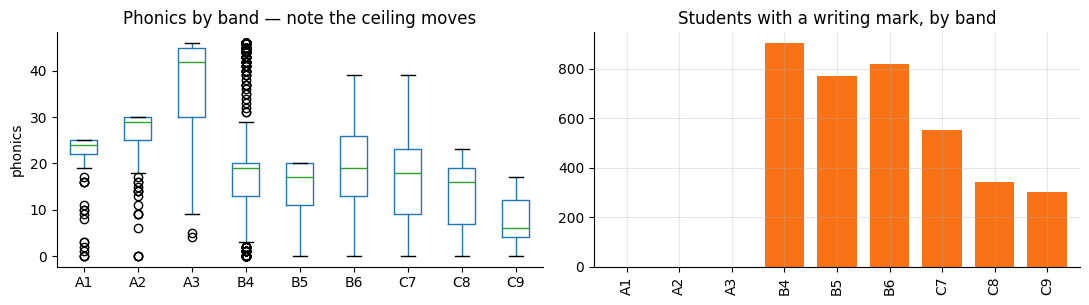

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
cohort.boxplot(column="phonics", by="band", ax=ax[0], grid=False)
ax[0].set_title("Phonics by band — note the ceiling moves"); ax[0].set_xlabel(""); ax[0].set_ylabel("phonics")
cohort.groupby("band").writing.count().plot.bar(ax=ax[1], color="#F97316", width=.75)
ax[1].set_title("Students with a writing mark, by band"); ax[1].set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.show()

**Phonics has a different ceiling in every band.** Maximum observed: **25** in A1, **30** in A2,
**46** in A3 — then it falls away through B and C to **17** in C9. That is not a cohort getting
worse at phonics as it advances; it is a longer paper at A3 and progressively less phonics
assessment afterwards. A score of 40 is only reachable if you sat the A3 paper.

**Writing is never administered to band A** — count 0 for A1, A2 and A3.

Phonics is also the only feature with real spread (sd **13.1**, against 1.6 for word reading and
3.2 for spelling), so it dominates the Euclidean distance k-means minimises. Cluster the whole
cohort at once and the algorithm substantially recovers *which paper the student sat* — §4 shows
this happening.

Two consequences, both now baked into the modules:

* **Clustering is scoped to a band group (A / B / C).** Within a band, scores are comparable.
* **`writing` is plottable but not clustered.** It is absent for a third of the cohort — and,
  before band scoping, was a proxy for band membership.

## 3 · Why the features must be standardised

k-means minimises Euclidean distance, so a wider-ranging feature contributes more variance and
therefore more say. Phonics runs 0–46; word reading and spelling run 0–10.

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = cohort[list(CLUSTER_FEATURES)].to_numpy(float)
raw_labels    = KMeans(4, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
scaled_labels = KMeans(4, n_init=10, random_state=RANDOM_STATE).fit_predict(StandardScaler().fit_transform(X))

def centroid_table(labels):
    return (pd.DataFrame(X, columns=list(CLUSTER_FEATURES)).assign(cluster=labels)
              .groupby("cluster").mean().round(1)
              .assign(n=pd.Series(labels).value_counts().sort_index()))

print("UNSCALED — cluster means in original units");  print(centroid_table(raw_labels).to_string())
print("\nSCALED — cluster means in original units");  print(centroid_table(scaled_labels).to_string())
print(f"\nagreement between the two partitions: "
      f"{pd.crosstab(raw_labels, scaled_labels).max(axis=1).sum()/len(X):.1%}")

UNSCALED — cluster means in original units
         phonics  word_reading_accuracy  word_spelling     n
cluster                                                     
0           43.2                    8.7            5.7  1201
1            6.2                    8.2            4.2  1292
2           28.7                    8.4            6.1  1022
3           18.3                    8.8            5.9  2268

SCALED — cluster means in original units
         phonics  word_reading_accuracy  word_spelling     n
cluster                                                     
0           40.8                    8.7            5.8  1442
1           14.2                    8.2            1.9  1586
2           17.7                    9.1            7.9  2557
3           20.3                    2.3            2.3   198

agreement between the two partitions: 66.9%


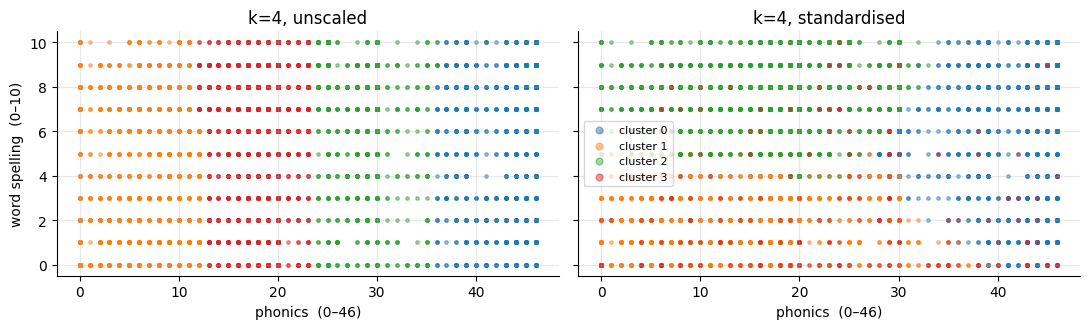

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, labels, title in ((ax[0], raw_labels, "unscaled"), (ax[1], scaled_labels, "standardised")):
    for c in np.unique(labels):
        a.scatter(X[labels == c, 0], X[labels == c, 2], s=6, alpha=.45, label=f"cluster {c}")
    a.set_xlabel("phonics  (0–46)"); a.set_title(f"k=4, {title}")
ax[0].set_ylabel("word spelling  (0–10)"); ax[1].legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

The unscaled fit cuts vertical stripes — four bands of phonics, with spelling and word reading
ignored (their cluster means barely move: 8.2–8.8 and 4.2–6.1). Standardising gives every skill an
equal vote and the groups become diagonal, i.e. real combinations of ability.
`ProfilingAlgorithm.cluster()` applies `StandardScaler` unconditionally for this reason.

## 4 · Choosing k, and choosing the scope

k is not a setting. For each `k` in 2…10 we fit and score, then take the best. Silhouette measures
how much closer a point sits to its own cluster than to the next nearest, from −1 to 1. It is
O(n²) in distances, so `cluster()` scores a seeded 3,000-point subsample — the ranking survives
and the choice of k stays reproducible.

Here both candidate scopes are fitted so the choice rests on evidence.

In [13]:
rows = cohort.to_dict("records")
cohort_run = algo.cluster(rows, CLUSTER_FEATURES, tier="Cohort")
band_runs  = algo.cluster_by_group(rows, CLUSTER_FEATURES, group_key="band_group")

print(f"cohort-wide   n={cohort_run.n_learners:5,}  k={cohort_run.k}  silhouette={cohort_run.best_silhouette}")
for g, r in band_runs.items():
    print(f"band {g}        n={r.n_learners:5,}  k={r.k}  silhouette={r.best_silhouette}")

labelled = sum(r.n_learners for r in band_runs.values())
print(f"\nlabelled by the band models: {labelled:,} / {len(cohort):,} "
      f"({len(cohort)-labelled} unbanded, below the minimum group size)")

cohort-wide   n=5,783  k=4  silhouette=0.3645
band A        n=1,717  k=5  silhouette=0.4292
band B        n=2,858  k=4  silhouette=0.4188
band C        n=1,205  k=2  silhouette=0.341

labelled by the band models: 5,780 / 5,783 (3 unbanded, below the minimum group size)


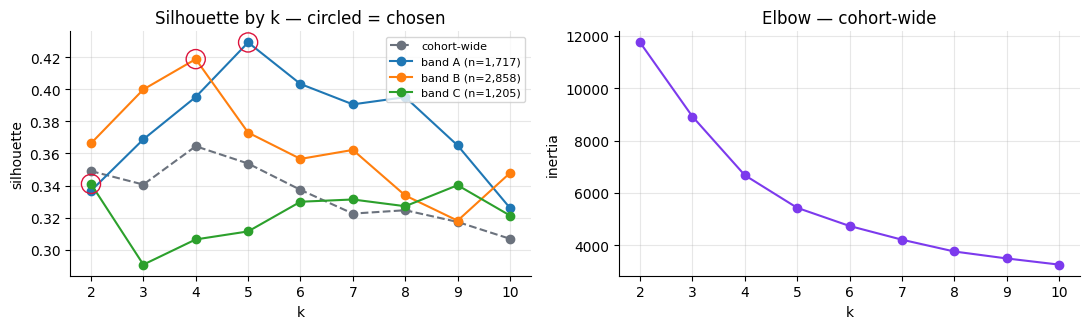

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))

ks = sorted(cohort_run.silhouette_by_k)
ax[0].plot(ks, [cohort_run.silhouette_by_k[k] for k in ks], "o--", color="#6B727D", label="cohort-wide")
for g, r in band_runs.items():
    ks = sorted(r.silhouette_by_k)
    ax[0].plot(ks, [r.silhouette_by_k[k] for k in ks], "o-", label=f"band {g} (n={r.n_learners:,})")
    ax[0].scatter([r.k], [r.best_silhouette], s=190, facecolors="none", edgecolors="crimson", zorder=5)
ax[0].set_xlabel("k"); ax[0].set_ylabel("silhouette"); ax[0].legend(fontsize=8)
ax[0].set_title("Silhouette by k — circled = chosen")

# Elbow, as the usual cross-check. Inertia always falls, so it corroborates rather than decides.
Xs = StandardScaler().fit_transform(X)
ax[1].plot(range(K_MIN, K_MAX+1),
           [KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(Xs).inertia_ for k in range(K_MIN, K_MAX+1)],
           "o-", color="#7C3AED")
ax[1].set_xlabel("k"); ax[1].set_ylabel("inertia"); ax[1].set_title("Elbow — cohort-wide")
plt.tight_layout(); plt.show()

**Every band model beats the cohort-wide one** (0.43 / 0.42 / 0.34 against 0.36), and each band
picks its own k off its own curve: A lands on 5, B on 4, C on 2.

And here is §2c's warning made concrete — what the cohort-wide model actually separated:

In [15]:
cohort_labels = cohort.student_id.map(cohort_run.labels).rename("cluster")
xt = pd.crosstab(cohort_labels, cohort.band)
print("cohort-wide cluster x NewBand — row %\n")
print((xt.div(xt.sum(axis=1), axis=0)*100).round(1).to_string())
print("\ncohort-wide centroids\n")
print(pd.DataFrame(cohort_run.centroids).to_string(index=False))

cohort-wide cluster x NewBand — row %

band        A1    A2    A3    B4    B5    B6    C7   C8   C9
cluster                                                     
Cohort 1  10.2  22.8  20.8  15.7  12.2  10.7   2.0  2.5  3.0
Cohort 2   1.6   6.8   4.9  26.7  20.0  17.9   8.7  6.9  6.6
Cohort 3   3.4   6.0   8.4  19.7  17.5  14.8  13.6  9.0  7.5
Cohort 4   0.0   8.8  56.8  19.4   0.0  10.3   4.6  0.0  0.0

cohort-wide centroids

 cluster    n  phonics  word_reading_accuracy  word_spelling
Cohort 1  198    20.27                   2.31           2.28
Cohort 2 1586    14.18                   8.21           1.90
Cohort 3 2557    17.73                   9.13           7.86
Cohort 4 1442    40.83                   8.74           5.85


`Cohort 4` — the high-phonics cluster, phonics 40.8 — is **56.8% band A3**, and contains zero
students from A1, B5, C8 or C9. It is not a discovered ability profile so much as "the students
who sat the A3 phonics paper". That is the confound band scoping removes.

**Decision: ship both.** The band models are the better answer and the dashboard's `By band`
toggle selects them, but the cohort model is a real partition and the comparison above is the
single most useful thing this analysis produced — so both are persisted (`cluster_cohort` and
`cluster_band` on `learner_scores`) and the dashboard lists all four models' k and silhouette
side by side.

The dashboard *opens* on the cohort model: four colours is a readable first impression, and
`By band` is what you switch to in order to interrogate it. Its band filter works in either
scope, so filtering the cohort view to band A shows the confound above directly — the
high-phonics cluster is nearly all that survives.

The rest of the notebook illustrates `band_runs`, the richer of the two.

## 5 · The band models

In [16]:
for g, r in band_runs.items():
    print(f"── band {g}   n={r.n_learners:,}   k={r.k}   silhouette={r.best_silhouette}")
    print(pd.DataFrame(r.centroids).to_string(index=False)); print()

── band A   n=1,717   k=5   silhouette=0.4292
cluster   n  phonics  word_reading_accuracy  word_spelling
    A 1  83    24.72                   1.39           2.49
    A 2 294    26.69                   7.99           2.74
    A 3 385    42.82                   8.11           1.87
    A 4 557    27.49                   9.11           8.23
    A 5 398    44.06                   8.96           7.56

── band B   n=2,858   k=4   silhouette=0.4188
cluster    n  phonics  word_reading_accuracy  word_spelling
    B 1   75    12.39                   2.51           1.40
    B 2 1011    13.36                   8.17           1.83
    B 3 1345    16.84                   9.10           7.61
    B 4  427    41.51                   9.12           7.56

── band C   n=1,205   k=2   silhouette=0.341
cluster   n  phonics  word_reading_accuracy  word_spelling
    C 1 403     9.15                   7.99           2.65
    C 2 802    16.12                   9.20           7.71



These are readable as clinical profiles rather than as artefacts of the timetable. Two patterns
recur in every band, which is itself reassuring — they are properties of learners, not of a paper:

* **A very small, very high-need group** — `A 1` (n=83) and `B 1` (n=75), both defined by word
  reading collapsing to ~1.4–2.5 out of 10. These are the learners a caseload review must not miss.
* **A reads-but-cannot-spell dissociation** — `A 2` / `A 3`, `B 2`, `C 1`: word reading at 8–9
  out of 10 with spelling at 1.8–2.7. Roughly 1,800 students across the cohort sit in this
  pattern, and it is exactly the kind of split that a single "reading age" number hides.

Band C splits only two ways. With phonics largely no longer assessed at that level, there is
genuinely less to separate on — k=2 is the honest answer, not a failure.

## 6 · The cohort in 3D — what the dashboard renders

In [17]:
import plotly.graph_objects as go
import plotly.io as pio
from itertools import cycle

# Emit the figure as compact plotly JSON rather than self-contained HTML. Left to its own
# devices under nbconvert, `fig.show()` inlines the whole ~4.7 MB plotly.js bundle into the
# saved notebook — which is 10x the size of everything else here combined, and re-inlined on
# every re-run. JupyterLab and VS Code both render this mimetype natively.
pio.renderers.default = "plotly_mimetype"

# = CLUSTER_COLORS in frontend/src/lib/constants.js — 12 hues, because band scoping yields 11
# clusters and a legend that reuses a colour is a legend that lies.
PALETTE = ["#FF2E45", "#2563EB", "#22A06B", "#7C3AED", "#F97316", "#EC4899",
           "#0891B2", "#CA8A04", "#7C2D12", "#4338CA", "#059669", "#BE123C"]

labels = {sid: lab for r in band_runs.values() for sid, lab in r.labels.items()}
plot_df = cohort.assign(cluster=cohort.student_id.map(labels)).dropna(subset=["cluster"])

AX = CLUSTER_FEATURES                      # the dashboard's default x, y, z
MAXES = {"phonics": 46, "word_reading_accuracy": 10, "word_spelling": 10, "writing": 24}

fig = go.Figure([
    go.Scatter3d(x=g[AX[0]], y=g[AX[1]], z=g[AX[2]], mode="markers",
                 name=f"{label}  (n={len(g):,})",
                 marker=dict(size=2.4, color=colour, opacity=.65))
    for (label, g), colour in zip(plot_df.groupby("cluster"), cycle(PALETTE))
])
fig.update_layout(
    height=580, margin=dict(l=0, r=0, t=34, b=0),
    title=f"Cohort by band-scoped cluster — {len(band_runs)} models, "
          f"{plot_df.cluster.nunique()} clusters, n={len(plot_df):,}",
    scene=dict(**{f"{a}axis": dict(title=f.replace('_', ' '), range=[0, MAXES[f]])
                  for a, f in zip("xyz", AX)}, aspectmode="cube"),
    legend=dict(itemsizing="constant"))
fig.show()

The banding along each axis is the discreteness from §2 — real students landing on the same
integer marks, not a rendering artefact. It is also why the silhouettes sit in the 0.3–0.4 range
rather than the 0.7 of a textbook example: thousands of students share *exactly* the same
coordinates, which caps the metric however good the partition is. The question worth asking is
not "is 0.43 high" but "are the groups interpretable" — §5 says they are.

## 7 · Sanity check — do the clusters just recover the bands?

Within a band group they cannot, by construction. But the *fine* band (A1 vs A2 vs A3) was never
shown to the algorithm, so agreement there would be evidence the clusters track something real.

In [18]:
xt = pd.crosstab(plot_df.cluster, plot_df.band)
print("cluster x NewBand — row %\n")
print((xt.div(xt.sum(axis=1), axis=0)*100).round(1).to_string())

cluster x NewBand — row %

band       A1    A2     A3    B4    B5    B6    C7    C8    C9
cluster                                                       
A 1      19.3  49.4   31.3   0.0   0.0   0.0   0.0   0.0   0.0
A 2       9.5  58.5   32.0   0.0   0.0   0.0   0.0   0.0   0.0
A 3       0.0   0.0  100.0   0.0   0.0   0.0   0.0   0.0   0.0
A 4      15.8  39.7   44.5   0.0   0.0   0.0   0.0   0.0   0.0
A 5       0.0   0.0  100.0   0.0   0.0   0.0   0.0   0.0   0.0
B 1       0.0   0.0    0.0  41.3  32.0  26.7   0.0   0.0   0.0
B 2       0.0   0.0    0.0  41.2  31.1  27.7   0.0   0.0   0.0
B 3       0.0   0.0    0.0  37.7  33.5  28.8   0.0   0.0   0.0
B 4       0.0   0.0    0.0  66.3   0.0  33.7   0.0   0.0   0.0
C 1       0.0   0.0    0.0   0.0   0.0   0.0  39.0  30.3  30.8
C 2       0.0   0.0    0.0   0.0   0.0   0.0  49.9  27.8  22.3


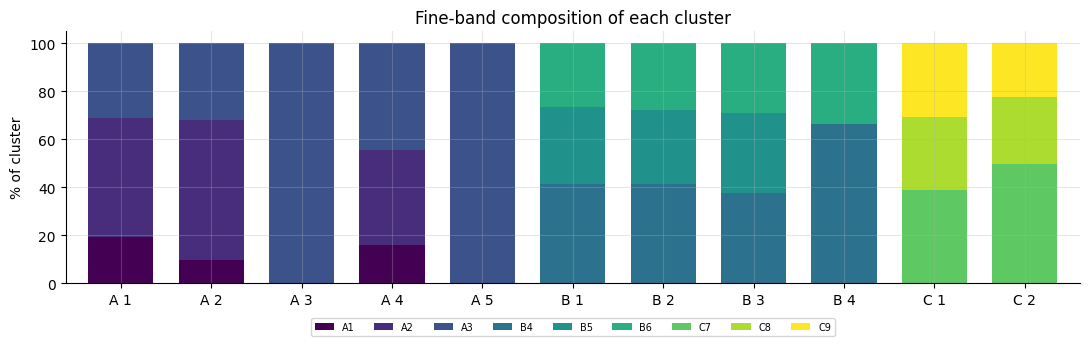

In [19]:
(xt.div(xt.sum(axis=1), axis=0)*100).plot.bar(stacked=True, figsize=(11, 3.6),
                                              colormap="viridis", width=.72)
plt.ylabel("% of cluster"); plt.xlabel(""); plt.xticks(rotation=0)
plt.title("Fine-band composition of each cluster")
plt.legend(fontsize=7, ncol=9, loc="upper center", bbox_to_anchor=(.5, -.12))
plt.tight_layout(); plt.show()

**Bands B and C pass cleanly.** Every one of their clusters spreads across all three fine bands
in roughly cohort proportions (`B 2` is 41/31/28 across B4/B5/B6), so those clusters are genuinely
orthogonal to `NewBand` — they add information rather than relabelling it.

**Band A does not, and it is worth being precise about why.** `A 3` and `A 5` are **100% band A3**.
Both are the high-phonics clusters (42.8 and 44.1), and from §2c the phonics paper tops out at 25
in A1 and 30 in A2 — so a score above 30 is only *reachable* by an A3 student. The ceiling effect
is between the fine bands as well as between the groups; scoping to A/B/C removes most of it but
not all.

Three honest readings of that, none of which changes the pipeline:

* `A 3` / `A 5` remain useful — "A3 students who are strong on phonics" is a real, actionable
  group, it is simply narrower than its label suggests.
* Scoping to the **nine fine bands** rather than three groups would remove the residue entirely.
  All nine have enough students (A1 is the smallest at 132, well over `MIN_GROUP`), so it is a
  one-argument change — `group_key="band"`. The cost is nine models and a longer legend.
* Leaving it, and documenting it, is defensible for a cohort dashboard whose job is to surface
  patterns for a therapist to interrogate rather than to publish an effect size.

## 8 · What ships

`scripts/ingest_dial_data.py` reproduces exactly the above — same loader, same `cluster()` and
`cluster_by_group()`, same `random_state=42` — and writes:

* `learner_scores` — one row per student: the four scores, `writing_genre`, `band_group`, and
  **both** cluster labels: `cluster_cohort` (all 5,783) and `cluster_band` (5,780 — the three
  unbanded learners fall below `MIN_GROUP`)
* `clustering_runs` — one row per model, four in total: `scope`, `tier`, chosen `k`,
  `best_silhouette`, the full `silhouette_by_k` sweep, `n_learners`, `features`

`GET /dashboard/clusters` serves those as a plain SELECT — no sklearn on the request path — and
`Graph.jsx` plots them, with a scope toggle, a band filter, and a caption listing all four
models so the comparison in §4 is on screen rather than only here.

**Findings, in order of how much they constrained the result:**

1. Phonics is band-ceilinged (max 25 / 30 / 46 across A1 / A2 / A3) and writing is never given to
   band A. Cohort-wide clustering therefore partly recovers which paper a student sat — its
   high-phonics cluster was 56.8% A3. **The band-scoped models are the better answer**, and the
   dashboard's `By band` toggle selects them. §2c, §4
2. The three writing genres are mutually exclusive — **collapsed to one `writing` mark**, which
   is plottable but not clustered. §2b
3. `FluencyMark` is `2 × Word_Reading_Accuracy`, r = 1.00 — **stored, never clustered.** §2a
4. The features span 0–46 and 0–10, so **standardisation is mandatory**, not a nicety. §3

In [20]:
summary = pd.DataFrame([
    {"model": f"band {g}", "features": ", ".join(r.features), "n": r.n_learners,
     "k": r.k, "silhouette": r.best_silhouette}
    for g, r in band_runs.items()
])
print(summary.to_string(index=False))
print(f"\ntotal labelled: {plot_df.cluster.nunique()} clusters over {len(plot_df):,} students "
      f"({len(cohort)-len(plot_df)} unclustered)\n")
print(plot_df.cluster.value_counts().sort_index().rename("students").to_frame().to_string())

 model                                      features    n  k  silhouette
band A phonics, word_reading_accuracy, word_spelling 1717  5      0.4292
band B phonics, word_reading_accuracy, word_spelling 2858  4      0.4188
band C phonics, word_reading_accuracy, word_spelling 1205  2      0.3410

total labelled: 11 clusters over 5,780 students (3 unclustered)

         students
cluster          
A 1            83
A 2           294
A 3           385
A 4           557
A 5           398
B 1            75
B 2          1011
B 3          1345
B 4           427
C 1           403
C 2           802
